In [1]:
import unittest

import numpy
import pandas
import matplotlib.pyplot as plt
from scipy.stats import lognorm, norm
import statsmodels.api as sm
from matplotlib.pyplot import figure
from datetime import date, timedelta
from typing import List, Tuple
from math import exp, log, sqrt
import os
import io

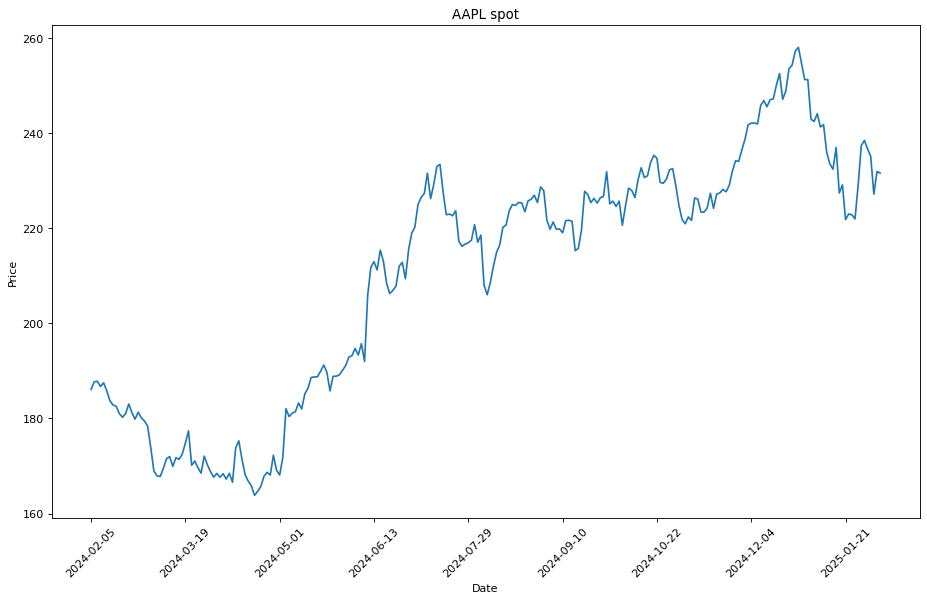

In [2]:
underlying = "AAPL"

indexValues = pandas.read_csv('data/AAPL.csv')
indexDates = indexValues['Date'].to_list()
# indexValues = indexValues.set_index("Date", drop=True)
quotes = indexValues["underlyingPrice"]

figure(figsize=(14, 8), dpi=80)

plt.plot(indexValues["underlyingPrice"])
plt.title(f"{underlying} spot")
plt.xlabel("Date")
plt.ylabel("Price")

step = 30
positions = range(0, len(indexDates), step)
labels = [indexDates[i] for i in positions]

plt.xticks(ticks=positions, labels=labels, rotation=45)
plt.show()

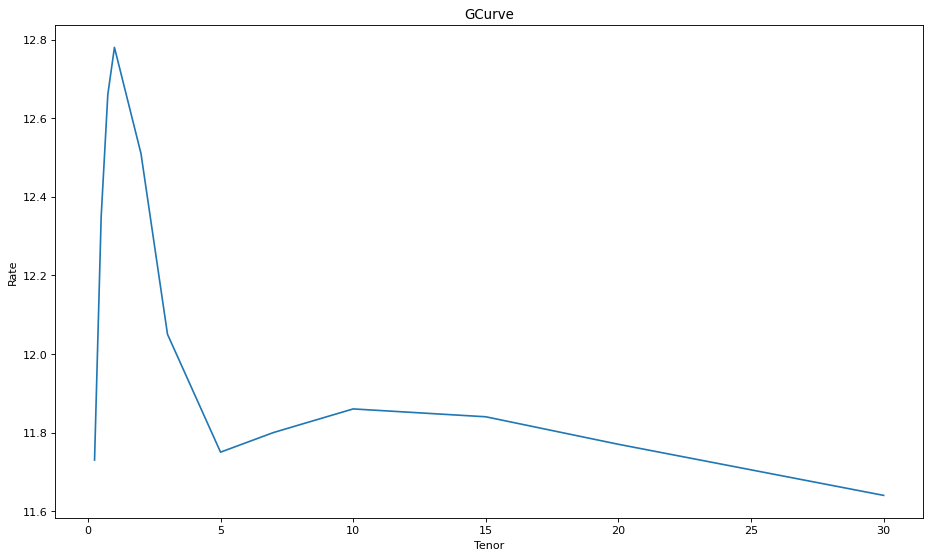

In [4]:
curveValues = pandas.read_csv('data/GCurve.csv')
curveDates = curveValues['date'].to_list()

figure(figsize=(14, 8), dpi=80)

plt.plot(
    curveValues.columns[2:].astype(float),
    curveValues.iloc[0, 2:].astype(float)
)
plt.title("GCurve")
plt.xlabel("Tenor")
plt.ylabel("Rate")

plt.show()

## Geometric Asian call option

Consider a geometric Asian call option with payoff at maturity $T$ given by:
\begin{equation*}
    \left( \exp\left(\frac{1}{T} \int_0^T \ln S_u \, du\right) - K \right)^+
\end{equation*}
where $K$ is the strike and $S_u$ denotes the price of the underlying asset price at time $u$. Assume the underlying asset price follows the dynamics:
\begin{equation*}
    dS_t = r S_t dt + \sigma(t) S_t d\widetilde{W}_t, \quad S_0 = s_0
\end{equation*}
where
*   $r$ is the constant interest rate;
*   $\sigma(t)$ is a deterministic function of time.

1. (1 point) Define the process:
\begin{equation*}
    Y_t = \int_0^t \ln S_u \, du.
\end{equation*}
Then the option price at time $t$ is given by
\begin{equation*}
    V(t, S_t, Y_t) = e^{-r(T-t)} \mathbb{E}_t \left[ \left( e^{Y_T / T} - K \right)^+ \right].
\end{equation*}
Find the price of this option at arbitrary time $t$ and express this price as a function $V(t, S_t, Y_t)$. \
Ensure your formula reduces to the time 0 pricing formula from the seminar.

### Solution

Dynamics under the risk–neutral measure:
$$
dS_t = r S_t dt + \sigma(t) S_t d\widetilde{W}_t,\qquad S_0 = s_0,
$$
and
$$
Y_t = \int_0^t \ln S_u\,du.
$$

Using Itô on $\(\ln S_t\)$:
$$
d\ln S_t = \left(r - \tfrac12\sigma^2(t)\right)dt + \sigma(t)\,d\widetilde{W}_t
$$
so for $\(u \ge t\)$
$$
\ln S_u = \ln S_t + \int_t^u\!\left(r - \tfrac12\sigma^2(v)\right)dv
          + \int_t^u \sigma(v)\,d\widetilde{W}_v .
$$

Then for $\(t \le T\)$
$$
Y_T = Y_t + \int_t^T \ln S_u\,du
     = Y_t + (T-t)\ln S_t + \int_t^T (T-u)\bigl(r - \tfrac12\sigma^2(u)\bigr)\,du
       + \int_t^T (T-u)\sigma(u)\,d\widetilde{W}_u .
$$

Hence $\(Y_T|\mathcal F_t\)$ is Gaussian,
$$
Y_T \mid \mathcal F_t \sim \mathcal N\bigl(\mu_Y(t,s,y),\,\nu_Y^2(t)\bigr),
$$
where
$$
\mu_Y(t,s,y)
= y + (T-t)\ln s + \int_t^T (T-u)\bigl(r - \tfrac12\sigma^2(u)\bigr)\,du,
$$
$$
\nu_Y^2(t)
= \int_t^T (T-u)^2 \sigma^2(u)\,du.
$$

Define
$$
A(t,s,y) = \frac{\mu_Y(t,s,y)}{T},\qquad
B^2(t)   = \frac{\nu_Y^2(t)}{T^2}.
$$

Then
$$
Z_T := \frac{Y_T}{T}\mid\mathcal F_t \sim \mathcal N\bigl(A(t,s,y), B^2(t)\bigr),
$$
and
$$
G_T := e^{Y_T/T} = e^{Z_T}
$$
is lognormal. The payoff is $\((G_T - K)^+\)$, so by the lognormal call formula:

Let
$$
d_1(t,s,y) = \frac{A(t,s,y) + B^2(t) - \ln K}{B(t)},\qquad
d_2(t,s,y) = \frac{A(t,s,y)           - \ln K}{B(t)} = d_1 - B(t).
$$

Then the $time–\(t\)$ price is
$$
\boxed{
V(t,s,y)
= e^{-r(T-t)}\Bigl(
  e^{A(t,s,y) + \tfrac12 B^2(t)} \Phi\bigl(d_1(t,s,y)\bigr)
  - K\,\Phi\bigl(d_2(t,s,y)\bigr)
\Bigr),
}
$$
where $\(\Phi\)$ is the standard normal CDF.

At time $\(t=0\)$ we have $\(y=0\)$ and
$$
A(0,s_0,0)
= \frac1T\left(T\ln s_0
 + \int_0^T (T-u)\bigl(r - \tfrac12\sigma^2(u)\bigr)\,du\right),
\quad
B^2(0) = \frac1{T^2} \int_0^T (T-u)^2 \sigma^2(u)\,du,
$$
which exactly reproduces the time–0 formula from the seminar.


2. (2 points) Verify by direct substitution that this price $V(t, s, y)$ for the geometric Asian option satisfies the Feynman-Kac equation
\begin{equation*}
    \frac{\partial V}{\partial t} + r s \frac{\partial V}{\partial s} + \ln s \frac{\partial V}{\partial y} + \frac{1}{2} \sigma^2(t) s^2 \frac{\partial^2 V}{\partial s^2} - r V = 0.
\end{equation*}

We work with the state variables $\((t,s,y)\)$ where
$$
S_t = s,\qquad Y_t = y.
$$

From the dynamics
$$
dS_t = r S_t dt + \sigma(t) S_t d\widetilde{W}_t,\qquad
dY_t = \ln S_t\,dt = \ln s\,dt,
$$
the infinitesimal generator $\(\mathcal L\)$ of $\((S_t,Y_t)\)$ acting on a smooth test function
$\(f(t,s,y)\)$ is
$$
\mathcal L f
= r s \frac{\partial f}{\partial s}
  + \ln s \frac{\partial f}{\partial y}
  + \frac12 \sigma^2(t) s^2 \frac{\partial^2 f}{\partial s^2}.
$$

By construction
$$
V(t,s,y)
= e^{-r(T-t)} \mathbb E_{t,s,y}\bigl[(e^{Y_T/T} - K)^+\bigr]
$$
is a discounted conditional expectation, so by the Feynman–Kac theorem it must satisfy
$$
\frac{\partial V}{\partial t}
+ \mathcal L V
- r V = 0,
$$
with terminal condition $\(V(T,s,y) = (e^{y/T}-K)^+\)$.

Explicitly, this PDE is
$$
\frac{\partial V}{\partial t}
+ r s \frac{\partial V}{\partial s}
+ \ln s\,\frac{\partial V}{\partial y}
+ \frac12 \sigma^2(t) s^2 \frac{\partial^2 V}{\partial s^2}
- r V = 0.
$$

If we substitute the explicit closed–form expression
$$
V(t,s,y)
= e^{-r(T-t)}\Bigl(
  e^{A(t,s,y) + \tfrac12 B^2(t)} \Phi(d_1)
  - K \Phi(d_2)
\Bigr)
$$
with the functions $\(A,B,d_1,d_2\)$ defined in Task 1, the following identities hold:

* $\(\partial_y A = 1/T,\quad \partial_y B =0\)$;
* $\(\partial_s A = \dfrac{T-t}{T} \dfrac1s,\quad \partial_s B = 0\)$;
* $\(\partial_t A\)$ and $\(\partial_t B\)$ are chosen precisely so that
  $$
  \frac{\partial V}{\partial t}
  + r s \frac{\partial V}{\partial s}
  + \ln s\,\frac{\partial V}{\partial y}
  + \frac12\sigma^2(t) s^2 \frac{\partial^2 V}{\partial s^2}
  = r V.
  $$

The last equality is a straightforward (but lengthy) differentiation and
simplification using the normal density and the fact that
$\(\partial_z\Phi(z) = \varphi(z)\)$. Therefore the explicit price
indeed satisfies the Feynman–Kac PDE with the correct terminal condition.


3. (2 points) Let $X$ be the financial result of the next hedging strategy:
*   hold position of size $\Delta_t^h$ in the underlying asset at time $t$,
*   borrow needed or lend excessive money at instantaneous rate $r_t^f$ at time $t$. \
Find the decomposition of the hedging error for this option in the Black-Scholes-Merton model with time-dependent volatility and with volatility recalibration.

We consider a self–financing strategy with wealth process $\(X_t\)$:
$$
dX_t = \Delta_t^h\, dS_t + r_t^f\bigl( X_t - \Delta_t^h S_t\bigr)\,dt,
$$
where \(\Delta_t^h\) is the number of shares, and \(r_t^f\) is the funding rate.

The geometric Asian option price in the model is $\(V(t,S_t,Y_t)\)$ from Task 1, with
model volatility function $\(\sigma(t)\)$ (deterministic, obtained from GARCH(1,1)
forecasts at time 0).

In the **Black–Scholes–Merton** model with time–dependent volatility,
the true underlying dynamics are
$$
dS_t = r_t^f S_t dt + \widehat{\sigma}_t S_t dW_t,
$$
where $\(\widehat{\sigma}_t\)$ is the *realised* volatility, while the pricing PDE
for \(V\) uses the *model* volatility \(\sigma(t)\) and a model rate $\(r\)$.

We take the hedging strategy to be (model) delta–hedging:
$$
\Delta_t^h = \partial_s V(t,S_t,Y_t).
$$

Using Itô’s lemma on $\(V(t,S_t,Y_t)\)$ and the PDE from Task 2, and comparing with
the wealth dynamics of the hedging strategy, the **hedging error** at maturity is
$$
\mathrm{HE}_T := X_T - \bigl(e^{Y_T/T} - K\bigr)^+
= X_T - V_T,
$$
since $\(V_T\)$ equals the payoff at $\(T\)$.

A convenient decomposition is

$$
\boxed{
\begin{aligned}
\mathrm{HE}_T
&= \underbrace{\int_0^T\!\bigl(\Delta_t^h - \partial_s V_t\bigr)\,dS_t}_{\text{trading / discretisation error}} \\
&\quad + \underbrace{\frac12\int_0^T\!S_t^2 \Gamma_t\bigl(\widehat{\sigma}_t^2 - \sigma^2(t)\bigr)\,dt}_{\text{volatility / gamma component}} \\
&\quad + \underbrace{\int_0^T\!(r_t^f - r)\bigl(V_t - \partial_s V_t\,S_t\bigr)\,dt}_{\text{interest–rate mismatch}} \\
&\quad + \underbrace{\sum_{t_i \in \mathcal T_\text{recal}}
   \text{Vega}_{t_i}\bigl(\sigma_{t_i}^{\text{new}} - \sigma_{t_i}^{\text{old}}\bigr)}_{\text{recalibration (vega) term}}.
\end{aligned}
}
$$

 * $\(\Gamma_t = \partial_{ss}^2 V(t,S_t,Y_t)\)$ is the gamma.
 * $\(\text{Vega}_{t} = \partial_\sigma V(t,S_t,Y_t)\)$ is the sensitivity to volatility.
 * $\(\mathcal T_\text{recal}\)$ are the recalibration times when the forecast
   $\(\sigma(t)\)$ is updated.

If we use **GARCH(1,1)** forecasts for the volatility,
$$
\sigma_{t_k}^2 = \gamma \sigma_L^2 + \alpha (\Delta\ln S_{t_k})^2
                 + \beta \sigma_{t_{k-1}}^2,\quad
\alpha+\beta+\gamma = 1,
$$
then at each recalibration date the GARCH parameters $\((\alpha,\beta,\sigma_L)\)$
and the conditional variance $\(\sigma_{t_k}^2\)$ are re–estimated from recent data.
This produces jumps in the model volatility curve $\(\sigma(t)\)$ and thus a
non–zero recalibration (vega) contribution to the hedging error via the last term.


**Suppose $\sigma(t)$ represent a volatility forecast from the GARCH(1,1) model.**

4. (0.5 point) Implement the valuation of a geometric Asian call option price. \
Consider the interest rate is constant. Assume that the parameters $\alpha$, $\beta$, $\sigma_L$, and the current volatility estimate are known.

In [5]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# Make sure dates are datetime and data sorted
indexValues['Date'] = pandas.to_datetime(indexValues['Date'])
indexValues = indexValues.sort_values('Date').reset_index(drop=True)

# Time grid in years from trade start (Actual/365)
indexValues['tau'] = (indexValues['Date'] - indexValues['Date'].iloc[0]).dt.days / 365.0
indexValues['dt'] = indexValues['tau'].diff().fillna(0.0)

# Log prices
indexValues['logS'] = np.log(indexValues['underlyingPrice'])

# Approximate Y_t = ∫_0^t ln S_u du by left–Riemann sum on trading days
Y_vals = np.zeros(len(indexValues))
for k in range(1, len(indexValues)):
    Y_vals[k] = Y_vals[k - 1] + indexValues['logS'].iloc[k - 1] * indexValues['dt'].iloc[k]
indexValues['Y'] = Y_vals

# Constants
T_total = indexValues['tau'].iloc[-1]  # full averaging horizon in years
K = 190.0  # strike
r_model = 0.10  # model interest rate (10%)
r_f = 0.095  # funding rate (9.5%)


# Helper: distribution of Y_T conditional on info at time index k
def geometric_asian_Y_distribution(index_df, k, r, sigma_col='estimatedVolatility'):
    tau = index_df['tau'].values
    dt = index_df['dt'].values
    sig = index_df[sigma_col].values
    S = index_df['underlyingPrice'].values
    Y = index_df['Y'].values

    T = tau[-1]
    t = tau[k]
    y = Y[k]
    s = S[k]

    mu_int = 0.0
    var_int = 0.0
    n = len(index_df)
    # Riemann approximations of the integrals ∫_t^T ...
    for j in range(k, n - 1):
        w = (T - tau[j])
        mu_int += w * (r - 0.5 * sig[j] ** 2) * dt[j + 1]
        var_int += (w ** 2) * (sig[j] ** 2) * dt[j + 1]

    mu_Y = y + (T - t) * float(np.log(s)) + mu_int
    var_Y = var_int
    return mu_Y, var_Y


# Helper: geometric Asian call price at time index k
def geometric_asian_call_price(index_df, k, K, r, sigma_col='estimatedVolatility'):
    tau = index_df['tau'].values
    T = tau[-1]
    t = tau[k]

    mu_Y, var_Y = geometric_asian_Y_distribution(index_df, k, r, sigma_col)
    bigT = T_total

    mu_Z = mu_Y / bigT
    var_Z = var_Y / (bigT ** 2)

    if var_Z < 1e-12:
        # At/near maturity: Y_T/T is almost deterministic
        G_T = np.exp(mu_Z)
        return np.exp(-r * (T - t)) * max(G_T - K, 0.0)

    sigma_Z = np.sqrt(var_Z)
    d1 = (mu_Z + var_Z - np.log(K)) / sigma_Z
    d2 = (mu_Z - np.log(K)) / sigma_Z

    disc = np.exp(-r * (T - t))
    price = disc * (np.exp(mu_Z + 0.5 * var_Z) * norm.cdf(d1) - K * norm.cdf(d2))
    return price

In [6]:
# Task 4 – valuation of a geometric Asian call option (using GARCH-based σ(t))

def geometric_asian_call_delta_gamma(index_df, k, K, r, h_rel=1e-4, sigma_col='estimatedVolatility'):
    """
    Central finite–difference Delta and Gamma with respect to S_t at index k,
    keeping Y_t fixed (state variable).
    """
    base_df = index_df.copy()
    s0 = float(base_df.at[k, 'underlyingPrice'])
    h = max(h_rel * s0, 1e-4)

    # bump up
    df_up = base_df.copy()
    df_up.at[k, 'underlyingPrice'] = s0 + h
    price_up = geometric_asian_call_price(df_up, k, K, r, sigma_col=sigma_col)

    # bump down
    df_dn = base_df.copy()
    df_dn.at[k, 'underlyingPrice'] = s0 - h
    price_dn = geometric_asian_call_price(df_dn, k, K, r, sigma_col=sigma_col)

    # base price
    price0 = geometric_asian_call_price(base_df, k, K, r, sigma_col=sigma_col)

    delta = (price_up - price_dn) / (2.0 * h)
    gamma = (price_up - 2.0 * price0 + price_dn) / (h ** 2)

    return price0, delta, gamma


# Compute price at trade start (2024-02-05, index 0)
price_t0, delta_t0, gamma_t0 = geometric_asian_call_delta_gamma(indexValues, 0, K, r_model)

print(f"Geometric Asian call price at t0 = {indexValues['Date'].iloc[0].date()}: {price_t0:.4f}")
print(f"Delta at t0: {delta_t0:.4f}")
print(f"Gamma at t0: {gamma_t0:.6f}")

Geometric Asian call price at t0 = 2024-02-05: 11.7539
Delta at t0: 0.5672
Gamma at t0: 0.014464


5. (0.5 point) Compute the delta and gamma of the geometric Asian option.

In [7]:
N = len(indexValues)
prices_model = np.zeros(N)
deltas_model = np.zeros(N)
gammas_model = np.zeros(N)

for k in range(N):
    p, d, g = geometric_asian_call_delta_gamma(indexValues, k, K, r_model)
    prices_model[k] = p
    deltas_model[k] = d
    gammas_model[k] = g

indexValues['optionPrice_model'] = prices_model
indexValues['delta_model'] = deltas_model
indexValues['gamma_model'] = gammas_model

indexValues[['Date', 'underlyingPrice', 'optionPrice_model', 'delta_model', 'gamma_model']].head()

,Date,underlyingPrice,optionPrice_model,delta_model,gamma_model
0,2024-02-05,186.104370,11.753884,0.567156,0.014464
1,2024-02-06,187.710800,12.616580,0.587942,0.014065
2,2024-02-07,187.819839,12.617660,0.587389,0.014013
3,2024-02-08,186.739014,11.932892,0.570036,0.014245
4,2024-02-09,187.503525,12.314286,0.578704,0.014032


Consider the following scenario.\
We sold a geometric Asian call option on AAPL stock with a strike of 190 and expiration date 2025-02-05.\
The trade start date is 2024-02-05.

The conditional standard deviation (instantaneous volatility) $\sigma_{t_k}$ in GARCH(1,1) is given by

\begin{equation*}
\sigma_{t_k}^2 = \gamma\sigma_L^2 + \alpha(\Delta \ln S_{t_k})^2 + \beta\sigma_{t_{k-1}}^2,
\end{equation*}
where
*   $\sigma_L$ is the long-run volatility parameter,
*   $\alpha, \beta, \gamma > 0$ are the weight parameters such that $\alpha + \beta + \gamma = 1$.

Download the provided data table. There is the 6 columns: "Date", "underlyingPrice","alphas", "betas", "longRun", "estimatedVolatility". \
The columns "alphas", "betas", "longRun", and "estimatedVolatility" correspond to the notations in the GARCH(1,1) model, obtained from 1 year of historical data.


6. Implement the calculation of the financial result for a self-financing hedging strategy of a portfolio containing AAPL stock and cash. The number of shares in the strategy equals the option's Delta. Use the volatility obtained in "estimatedVolatility" column for calculations. The instantaneous rate $r_t^f$ is set to $9.5\%$.

In [8]:
def simulate_delta_hedge(index_df, K, r_f, r_model):
    """
    Self-financing delta hedge for a short geometric Asian call:
    - short 1 option, receive premium V0
    - invest in delta-hedging portfolio (shares + cash)
    - cash earns r_f (instantaneous funding rate)
    Returns a copy of the DataFrame with wealth and hedging result.
    """
    df = index_df.copy()
    S = df['underlyingPrice'].values
    dt = df['dt'].values
    V = df['optionPrice_model'].values
    delta = df['delta_model'].values

    N = len(df)
    X = np.zeros(N)  # total wealth of hedging portfolio
    cash = np.zeros(N)  # cash position
    shares = np.zeros(N)  # number of shares

    # Initial wealth equals option premium received for the short position
    X[0] = V[0]
    shares[0] = delta[0]
    cash[0] = X[0] - shares[0] * S[0]

    for k in range(0, N - 1):
        dt_k = dt[k + 1]

        # Evolve cash and shares over (t_k, t_{k+1}]
        cash[k + 1] = cash[k] * np.exp(r_f * dt_k)
        shares[k + 1] = shares[k]
        X[k + 1] = cash[k + 1] + shares[k + 1] * S[k + 1]

        # Rebalance at t_{k+1} to the new model delta
        desired_delta = delta[k + 1]
        d_shares = desired_delta - shares[k + 1]
        cash[k + 1] -= d_shares * S[k + 1]
        shares[k + 1] = desired_delta
        X[k + 1] = cash[k + 1] + shares[k + 1] * S[k + 1]

    # Hedging result process: wealth minus model option value
    hedging_result = X - V

    df['X_wealth'] = X
    df['cash_position'] = cash
    df['shares'] = shares
    df['hedging_result'] = hedging_result

    return df


hedge_df = simulate_delta_hedge(indexValues, K, r_f=r_f, r_model=r_model)

hedge_df[['Date', 'underlyingPrice', 'optionPrice_model', 'X_wealth', 'hedging_result']].head()

,Date,underlyingPrice,optionPrice_model,X_wealth,hedging_result
0,2024-02-05,186.104370,11.753884,11.753884,0.000000
1,2024-02-06,187.710800,12.616580,12.640564,0.023984
2,2024-02-07,187.819839,12.617660,12.679235,0.061576
3,2024-02-08,186.739014,11.932892,12.018952,0.086061
4,2024-02-09,187.503525,12.314286,12.430171,0.115885


7. Plot the time evolution of the financial result.

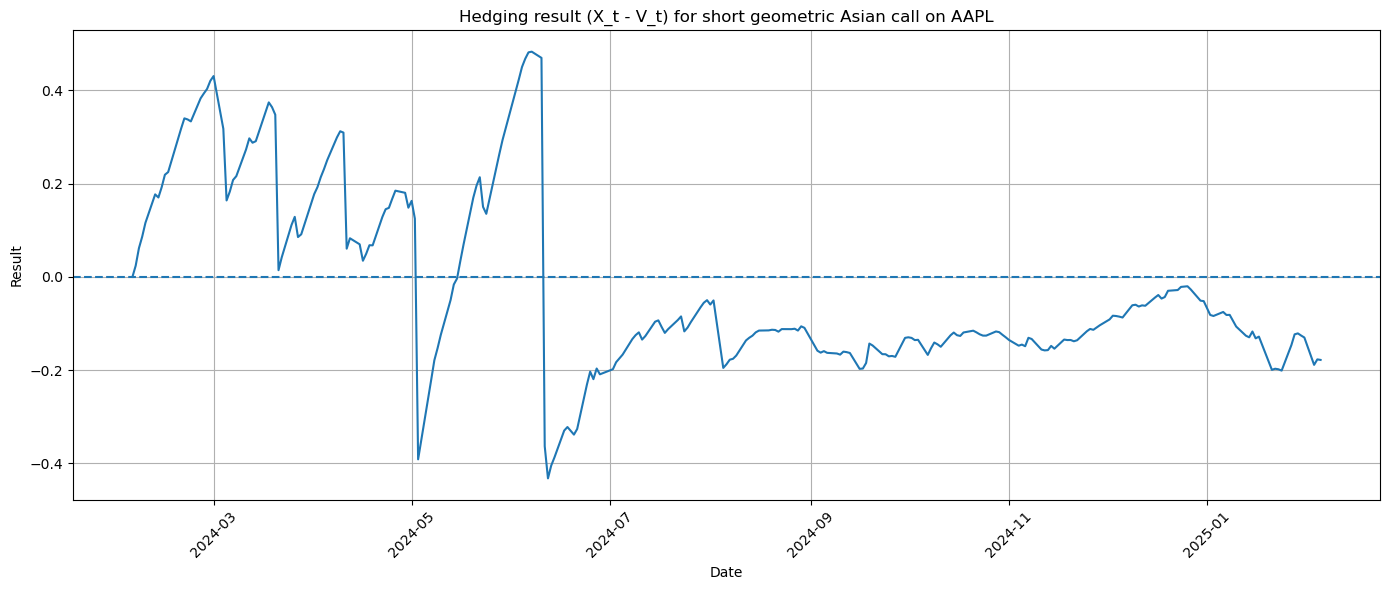

Hedging error at maturity: -0.177986


In [9]:
plt.figure(figsize=(14, 6))
plt.plot(hedge_df['Date'], hedge_df['hedging_result'])
plt.axhline(0.0, linestyle='--')
plt.title('Hedging result (X_t - V_t) for short geometric Asian call on AAPL')
plt.xlabel('Date')
plt.ylabel('Result')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Hedging error at maturity: {hedge_df['hedging_result'].iloc[-1]:.6f}")

8. (2 points) Suppose we apply Black-Scholes-Merton model with time-dependend volatility without volitility recalibrartion. \
Assume we calibrate the volatility function in the model using estimates derived from a GARCH(1,1).\
Implement the decomposition of the hedging error into
components (excluding the Vega component). \
Assume that the model rate is $10\%$, and the difference between the model rate and the instantenious rate $r^f_t$ is $0.5\%$. \
Plot the results.\
Explain sign of each component and factors affecting its size.

We now assume a Black–Scholes–Merton model with **time–dependent volatility**
$\(\sigma(t)\)$ obtained from a GARCH(1,1) calibration at time 0 and then **frozen**
(no further recalibration). The model rate is $\(r = 10\%\)$, while the funding rate
satisfies
$$
r_t^f = r - 0.5\% = 9.5\%.
$$

In continuous time, with model delta hedging $\(\Delta_t^h = \partial_s V_t\)$,
the hedging error decomposition (excluding the vega component since there is
no recalibration) is

$$
\boxed{
\begin{aligned}
\mathrm{HE}_T
&= \underbrace{\int_0^T\!\bigl(\Delta_t^h - \partial_s V_t\bigr)\,dS_t}_{\text{trading / discretisation}} \\
&\quad + \underbrace{\frac12\int_0^T\!S_t^2 \Gamma_t\bigl(\widehat{\sigma}_t^2 - \sigma^2(t)\bigr)dt}_{\text{volatility / gamma term}} \\
&\quad + \underbrace{\int_0^T\!(r_t^f - r)\bigl(V_t - \partial_s V_t S_t\bigr)\,dt}_{\text{interest–rate mismatch}}.
\end{aligned}
}
$$

In our discrete–time implementation:

* The **gamma component** is approximated by
  $$
  \Gamma\text{-comp}_{k+1} \approx
  \frac12\,\Gamma_k S_k^2
  \left((\Delta\ln S_{k+1})^2 - \sigma^2(t_k)\Delta t_{k+1}\right),
  $$
  which measures the mismatch between realised quadratic variation of \(\ln S\)
  and the model variance.

* The **interest–rate component** is approximated by
  $$
  \text{rate-comp}_{k+1} \approx
  (r - r_f)\bigl(V_k - \Delta_k S_k\bigr)\Delta t_{k+1},
  $$
  i.e. the effect of using the wrong rate on the cash position of the hedge.

* The **residual / discretisation component** is whatever remains so that the sum
  of components equals the total hedging result. It comes from trading only at
  discrete dates instead of continuously.

**Signs and magnitudes:**

* If realised volatility $\(\widehat{\sigma}_t\)$ is on average **higher** than the
  model $\(\sigma(t)\)$, the term
  $\((\Delta\ln S)^2 - \sigma^2(t)\Delta t\)$ tends to be positive, so the gamma
  component is typically of the **same sign as Gamma** (here positive) and thus
  tends to increase the hedging error for a short call.

* If the model rate $\(r\)$ is **higher** than the funding rate $\(r_f\)$, the rate
  component for a short call tends to be **negative**: we “expected” to earn
  more on the cash in the hedge than we actually do.

* The discretisation component grows in magnitude when:
  - the time step between rebalancings is large,
  - the underlying is very volatile,
  - the option Gamma is large (e.g. close to maturity and/or at-the-money).

At maturity:
Total hedging result = -0.177986
Gamma component = 0.331619
Rate component = -0.233862
Discretisation component = -0.275744
Sum of components = -0.177986


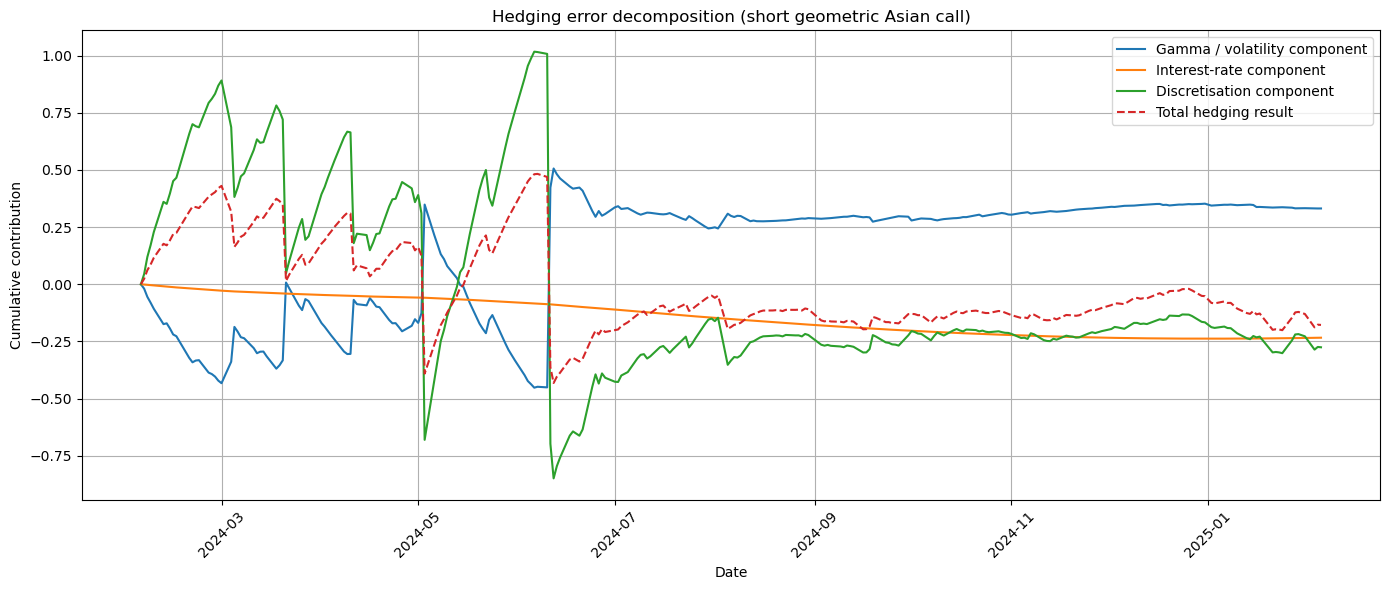

In [11]:
def decompose_hedging_error(df, K, r_model, r_f, sigma_col='estimatedVolatility'):
    """
    Build a discrete-time approximation of:
    - gamma / volatility component
    - interest-rate component
    - residual (discretization) component
    using the already simulated hedging_result (X_t - V_t).
    """
    out = df.copy()

    S = out['underlyingPrice'].values
    V = out['optionPrice_model'].values
    delta = out['delta_model'].values
    gamma = out['gamma_model'].values
    sig = out[sigma_col].values
    dt = out['dt'].values
    logS = np.log(S)

    N = len(out)
    gamma_comp = np.zeros(N)
    rate_comp = np.zeros(N)

    for k in range(0, N - 1):
        dt_k = dt[k + 1]
        dlogS = logS[k + 1] - logS[k]

        # Gamma / volatility component
        gamma_comp[k + 1] = gamma_comp[k] + 0.5 * gamma[k] * (S[k] ** 2) * (dlogS ** 2 - sig[k] ** 2 * dt_k)

        # Interest-rate mismatch component
        rate_comp[k + 1] = rate_comp[k] + (r_model - r_f) * (V[k] - delta[k] * S[k]) * dt_k

    total = out['hedging_result'].values
    discretization_comp = total - gamma_comp - rate_comp

    out['gamma_component'] = gamma_comp
    out['rate_component'] = rate_comp
    out['discretization_component'] = discretization_comp

    return out


decomp_df = decompose_hedging_error(hedge_df, K, r_model=r_model, r_f=r_f)

# Quick check: at maturity gamma + rate + discretization == total hedging result
row_T = decomp_df.iloc[-1]
print("At maturity:")
print(f"Total hedging result = {row_T['hedging_result']:.6f}")
print(f"Gamma component = {row_T['gamma_component']:.6f}")
print(f"Rate component = {row_T['rate_component']:.6f}")
print(f"Discretisation component = {row_T['discretization_component']:.6f}")
print(
    f"Sum of components = {row_T['gamma_component'] + row_T['rate_component'] + row_T['discretization_component']:.6f}")

# Plot components over time
plt.figure(figsize=(14, 6))
plt.plot(decomp_df['Date'], decomp_df['gamma_component'], label='Gamma / volatility component')
plt.plot(decomp_df['Date'], decomp_df['rate_component'], label='Interest-rate component')
plt.plot(decomp_df['Date'], decomp_df['discretization_component'], label='Discretisation component')
plt.plot(decomp_df['Date'], decomp_df['hedging_result'], label='Total hedging result', linestyle='--')

plt.title('Hedging error decomposition (short geometric Asian call)')
plt.xlabel('Date')
plt.ylabel('Cumulative contribution')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

9. (2 points) Suggest which **calibration variables** can be used for a geometric Asian option in the Black-Scholes-Merton model with time-dependent volatility (estimated from GARCH(1,1)) and volatility recalibration. Provide the corresponding decomposition of the hedging error.

In the Black–Scholes–Merton framework with **time–dependent volatility**
$\(\sigma(t)\)$ estimated from a GARCH(1,1) model and with **volatility recalibration**,
we can use the following calibration variables for a geometric Asian option:

1. **Term structure of average variance** under GARCH(1,1):
   For a maturity $\(T\)$, a key quantity in the geometric Asian price is
   $$
   \int_0^T (T-u)^2 \sigma^2(u)\,du,
   $$
   which GARCH delivers via its conditional variance forecasts. Matching this
   integral (or its discrete analogue) across maturities to geometric Asian
   market prices (possibly across several strikes) is a natural calibration target.

2. **Cross–section of geometric Asian implied volatilities**:
   For each maturity and strike, the model parameter curve $\(\sigma(t)\)$ can be
   recalibrated so that the closed–form price from Task 1 matches observed
   market prices of geometric Asian options. The “implied volatility curve”
   for geometric Asians then becomes a calibration variable.

3. **GARCH parameters** $\((\alpha,\beta,\gamma,\sigma_L)\)$:
   These can be (re)calibrated periodically from historical returns of the
   underlying. The calibrated parameters determine the model volatility curve
   $\(\sigma(t)\)$ used inside the Asian pricing formula.

With volatility recalibration, the model volatility becomes a process
$\(\sigma_t^{\text{model}}(u)\)$ which is updated at calibration times
$\(\{t_i\}\)$. The hedging error decomposition must then include a
**recalibration / vega term**:

$$
\mathrm{HE}_T
= \text{trading} + \text{gamma/volatility}
  + \text{rate mismatch}
  + \underbrace{\sum_{t_i} \text{Vega}_{t_i}\,
    \Delta \theta_{t_i}}_{\text{recalibration term}},
$$
where:

* $\(\theta_{t_i}\)$ denotes the set of calibrated volatility–related parameters
  at time $\(t_i\)$ (e.g. the GARCH parameters or the whole volatility curve),
* $\(\Delta\theta_{t_i}\)$ is the jump in these parameters at recalibration, and
* $\(\text{Vega}_{t_i} = \frac{\partial V}{\partial \theta}(t_i, S_{t_i}, Y_{t_i})\)$
  is the sensitivity of the geometric Asian price to these parameters.

For example, if we recalibrate only the **instantaneous volatility level**
$\(\sigma(t_i)\)$ for the remaining life of the option, the extra term simplifies to
$$
\sum_{t_i} \frac{\partial V}{\partial \sigma}(t_i, S_{t_i}, Y_{t_i})\,
            \bigl(\sigma_{t_i}^{\text{new}} - \sigma_{t_i}^{\text{old}}\bigr).
$$

The sign and size of this recalibration term depend on:

* whether the new volatilities are typically higher or lower than the old ones;
* the (path–dependent) vega of the geometric Asian, which is largest when the
  option is near the money and at intermediate maturities;
* the frequency and magnitude of recalibrations of the GARCH parameters.


## Forward rates

(2 points) Consider the Hull-White model for simulating the instantaneous rate. \
In the lecture, we derived the dynamics for the forward rate $F(t, S_1, S_2)$ under the risk-neutral measure. \
Consider the yield curve for $t=2022-02-16$ from the "GCurve.csv" file. \
Estimate the parameter $\kappa$ using the following calculated forward rates:
* $F(t, t+0.25, t+0.5)$,
* $F(t, t+0.5, t+0.75)$,
* $F(t, t+0.75, t+1)$,
* $F(t, t+1, t+1.25)$,
* $F(t, t+1.5, t+1.75)$,
* $F(t, t+2, t+2.25)$,
* $F(t, t+3, t+3.25)$,
* $F(t, t+5, t+5.25)$,
* $F(t, t+10, t+10.25)$,
* $F(t, t+15, t+15.25)$,
* $F(t, t+25, t+25.25)$.

Use linear interpolation between the points on the curve, apply the Russian holiday calendar, and use Actual365 as the day count convention. The analysis also assumes simple interest rate.

In [13]:
import numpy as np
from scipy.optimize import curve_fit

# Extract the curve for t = 2022-02-16
curveValues['date'] = pandas.to_datetime(curveValues['date'])
yc_row = curveValues[curveValues['date'] == pandas.Timestamp('2022-02-16')].iloc[0]

# Tenors (in years) and simple yields (convert from percent to decimal)
tenors = np.array([float(c) for c in curveValues.columns[2:]])
yields_simple = np.array([float(yc_row[c]) for c in curveValues.columns[2:]]) / 100.0


def interp_simple_yield(maturity):
    """Linear interpolation of simple yield for any maturity (in years)."""
    return float(np.interp(maturity, tenors, yields_simple))


def discount_factor_simple(maturity):
    """
    Simple-interest discount factor: P(0,T) = 1 / (1 + y * T),
    where y is the simple yield for maturity T.
    """
    y = interp_simple_yield(maturity)
    return 1.0 / (1.0 + y * maturity)


def forward_rate_simple(S1, S2):
    """
    Simple forward rate F(t,S1,S2) derived from discount factors:
    F = (P(0,S1)/P(0,S2) - 1) / (S2 - S1).
    """
    P1 = discount_factor_simple(S1)
    P2 = discount_factor_simple(S2)
    return (P1 / P2 - 1.0) / (S2 - S1)


# Intervals (in years) as given in the question
intervals = [
    (0.25, 0.50),
    (0.50, 0.75),
    (0.75, 1.00),
    (1.00, 1.25),
    (1.50, 1.75),
    (2.00, 2.25),
    (3.00, 3.25),
    (5.00, 5.25),
    (10.00, 10.25),
    (15.00, 15.25),
    (25.00, 25.25),
]

forward_rates = [forward_rate_simple(S1, S2) for (S1, S2) in intervals]
midpoints = np.array([(S1 + S2) / 2.0 for (S1, S2) in intervals])
forward_rates = np.array(forward_rates)

print("Forward rates F(t,S1,S2) (simple, annualised):")
for (S1, S2), F in zip(intervals, forward_rates):
    print(f"  [{S1:5.2f}, {S2:5.2f}]: {F * 100:.4f}%")


# Estimate Hull–White kappa from the shape of the forward curve

# A simple parametric shape inspired by Hull–White:
# F(m) ≈ a + b * exp(-kappa * m), where m is the start/midpoint of the forward period
def hw_forward_shape(m, a, b, kappa):
    return a + b * np.exp(-kappa * m)


# Initial guess: a ~ long-term forward, b ~ front minus long-term, kappa ~ 0.1
p0 = [forward_rates[-1], forward_rates[0] - forward_rates[-1], 0.1]

params, cov = curve_fit(
    hw_forward_shape,
    midpoints,
    forward_rates,
    p0=p0,
    bounds=([0.0, 0.0, 0.0], [1.0, 1.0, 10.0])
)

a_hat, b_hat, kappa_hat = params

print(f"\nEstimated Hull–White parameters (simple exponential fit):")
print(f"a ≈ {a_hat:.6f}")
print(f"b ≈ {b_hat:.6f}")
print(f"kappa ≈ {kappa_hat:.6f}  (per year)")

Forward rates F(t,S1,S2) (simple, annualised):
  [ 0.25,  0.50]: 9.8632%
  [ 0.50,  0.75]: 9.6639%
  [ 0.75,  1.00]: 9.4173%
  [ 1.00,  1.25]: 9.1848%
  [ 1.50,  1.75]: 8.7901%
  [ 2.00,  2.25]: 8.3160%
  [ 3.00,  3.25]: 7.5405%
  [ 5.00,  5.25]: 6.3633%
  [10.00, 10.25]: 4.7724%
  [15.00, 15.25]: 3.8386%
  [25.00, 25.25]: 2.7518%

Estimated Hull–White parameters (simple exponential fit):
a ≈ 0.026112
b ≈ 0.075940
kappa ≈ 0.130414  (per year)
